# Taller final APO III: clasificación de calidad de frutas

Este notebook implementa una solución base para el caso de estudio del README usando tres categorías finales: **bueno**, **regular** y **malo**.

## CRISP-DM
1. Comprensión del negocio (Sección 1)
2. Comprensión de los datos (Sección 2)
3. Verificación de balance (Sección 3) + Preparación de los datos (Sección 4)
4. Vectorización y Modelado (Secciones 5, 6, 8)
5. Evaluación (Secciones 3, 7)
6. Despliegue / uso del modelo (Secciones 9, 10)

## Estructura esperada de los datos
Se espera una carpeta con subcarpetas por clase:

- `data/bueno/`
- `data/regular/`
- `data/malo/`

Cada subcarpeta debe contener imágenes `.jpg`, `.png` o `.jpeg`.

In [2]:
import subprocess, sys, importlib, pkgutil, os
required = ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "Pillow", "tensorflow", "joblib"]
missing = [p for p in required if not importlib.util.find_spec(p)]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"

try:
    import tensorflow as tf
    from tensorflow import keras
except ImportError:
    raise RuntimeError(
        "TensorFlow es obligatorio para la CNN. "
        "Asegúrate de usar Python 3.10-3.12 y ejecutar: pip install tensorflow"
    )

I0000 00:00:1780619237.114603   31923 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780619237.114947   31923 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780619237.151700   31923 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780619237.976253   31923 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## 1. Comprensión del negocio

El objetivo es automatizar la clasificación visual de frutas para apoyar una línea de empaque o un sistema de inspección básica.

Las categorías finales del proyecto son:
- bueno
- regular
- malo

Estas etiquetas pueden representar fruta visualmente apta, con defectos leves o con deterioro evidente.

In [3]:
# Ruta base del dataset. Ajusta esta variable si tus imágenes están en otro lugar.
DATA_DIR = Path("data")
CLASS_NAMES = ["bueno", "regular", "malo"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if not DATA_DIR.exists():
    print(f"La carpeta {DATA_DIR.resolve()} no existe todavía.")
    print("Crea la estructura data/bueno, data/regular y data/malo, o cambia DATA_DIR.")

rows = []
if DATA_DIR.exists():
    for class_name in CLASS_NAMES:
        class_dir = DATA_DIR / class_name
        if class_dir.exists():
            for file_path in class_dir.rglob("*"):
                if file_path.suffix.lower() in IMAGE_EXTENSIONS:
                    rows.append({"filepath": str(file_path), "label": class_name})

images_df = pd.DataFrame(rows)
print(f"Imágenes encontradas: {len(images_df)}")
images_df.head()

if not images_df.empty:
    display(images_df.sample(min(5, len(images_df)), random_state=42))
    print(images_df["label"].value_counts())

Imágenes encontradas: 23064


,filepath,label
1122,data/bueno/Apple_Good/IMG_9632.JPG,bueno
22882,data/malo/Pomegranate_Bad/IMG_20190829_072034_...,malo
6757,data/bueno/Pomegranate_Good/20190820_145636_23...,bueno
17089,data/malo/Apple_Bad/IMG_20190910_172328.jpg,malo
20774,data/malo/Orange_Bad/IMG20200728185943.jpg,malo


label
bueno      11664
malo        6788
regular     4612
Name: count, dtype: int64


## 2. Comprensión de los datos

Se revisa la distribución de clases y algunos ejemplos visuales para verificar variabilidad, fondo, iluminación y calidad general de las imágenes.

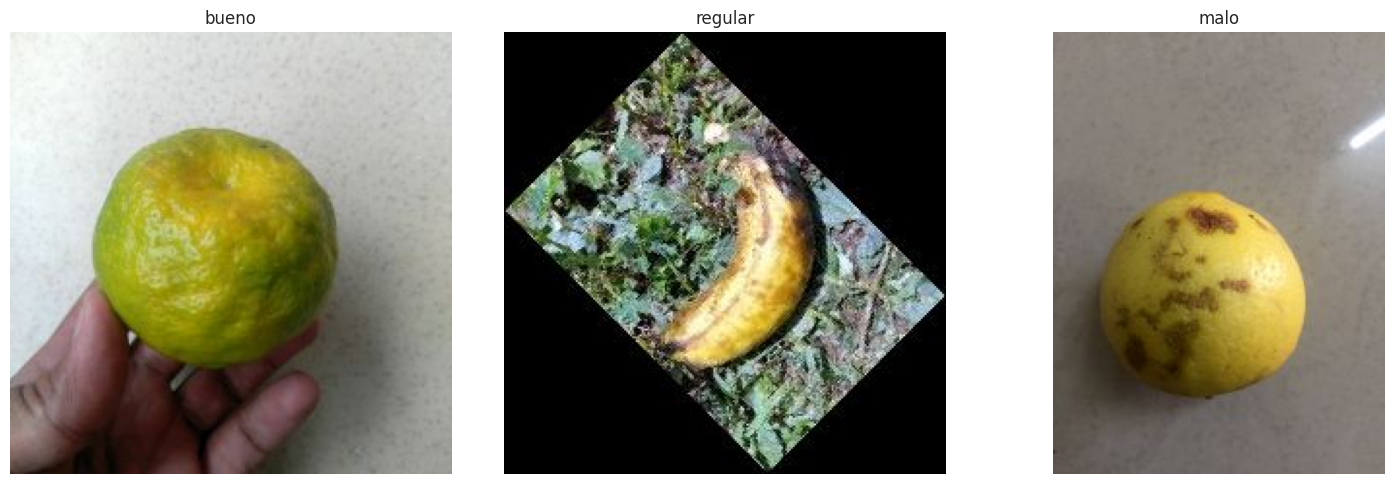

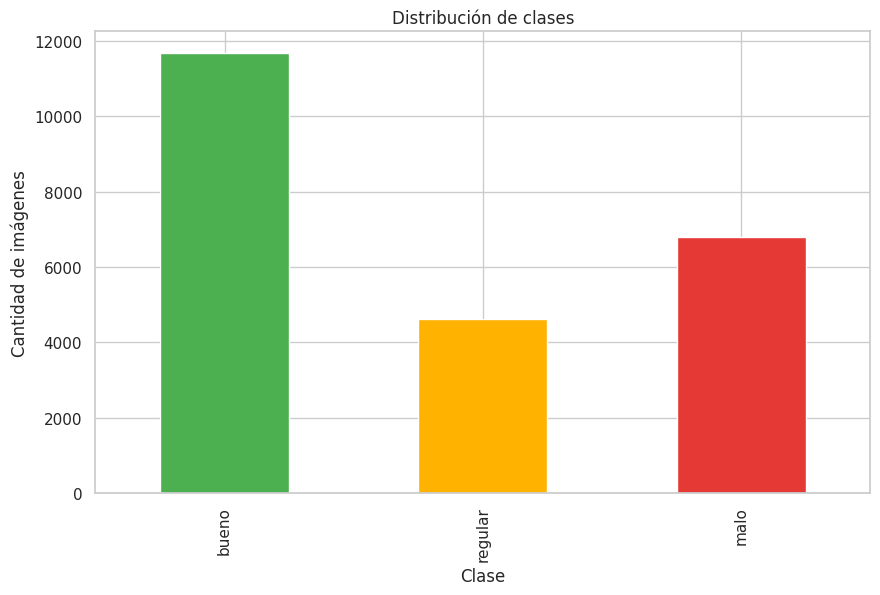

In [4]:
if not images_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, class_name in zip(axes, CLASS_NAMES):
        subset = images_df[images_df["label"] == class_name]
        if subset.empty:
            ax.axis("off")
            ax.set_title(f"Sin imágenes: {class_name}")
            continue
        sample_path = subset.sample(1, random_state=42)["filepath"].iloc[0]
        img = Image.open(sample_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(class_name)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    counts = images_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    counts.plot(kind="bar", color=["#4caf50", "#ffb300", "#e53935"])
    plt.title("Distribución de clases")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad de imágenes")
    plt.show()

## 3. Verificación de balance de clases

Se verifica que las clases estén balanceadas. Si hay desbalanceo severo, se recomienda usar `class_weight` (ya configurado) o técnicas de sobremuestreo como SMOTE.

In [5]:
if not images_df.empty:
    counts = images_df["label"].value_counts()
    print("Distribución de clases:")
    for cls in CLASS_NAMES:
        count = counts.get(cls, 0)
        pct = count / len(images_df) * 100
        print(f"  {cls}: {count} ({pct:.1f}%)")
    min_count = counts.min()
    max_count = counts.max()
    ratio = max_count / min_count if min_count > 0 else float("inf")
    print(f"\nRelación mayor/menor: {ratio:.1f}x")
    if ratio > 2.0:
        print("⚠️  Desbalanceo significativo. Considera aplicar SMOTE o aumentar datos de clases minoritarias.")
    else:
        print("✅ Clases razonablemente balanceadas.")

Distribución de clases:
  bueno: 11664 (50.6%)
  regular: 4612 (20.0%)
  malo: 6788 (29.4%)

Relación mayor/menor: 2.5x
⚠️  Desbalanceo significativo. Considera aplicar SMOTE o aumentar datos de clases minoritarias.


### Balanceo por subcarpeta de fruta

Si hay subcarpetas por tipo de fruta (ej. `Pomegranate_Good` con 5940 imágenes), se reduce cada subcarpeta a 1.5x la mediana para evitar que una fruta domine la clase.

In [6]:
if not images_df.empty:
    parent_dirs = set(Path(p).parent.name for p in images_df["filepath"])
    if parent_dirs:
        for cls in CLASS_NAMES:
            cls_mask = images_df["label"] == cls
            sub_names = images_df.loc[cls_mask, "filepath"].apply(lambda p: Path(p).parent.name)
            sub_counts = sub_names.value_counts()
            if len(sub_counts) <= 1:
                continue
            median_count = int(sub_counts.median())
            max_allowed = max(int(median_count * 1.5), 1)
            keep = []
            for sub_name in sub_counts.index:
                sub_mask = cls_mask & (images_df["filepath"].apply(lambda p: Path(p).parent.name) == sub_name)
                subset = images_df[sub_mask]
                if len(subset) > max_allowed:
                    subset = subset.sample(n=max_allowed, random_state=42)
                keep.append(subset)
            images_df = pd.concat([images_df[~cls_mask]] + keep)

    print(f"Imágenes después de balancear por fruta: {len(images_df)}")
    counts = images_df["label"].value_counts()
    for cls in CLASS_NAMES:
        print(f"  {cls}: {counts.get(cls, 0)}")

Imágenes después de balancear por fruta: 18849
  bueno: 7449
  regular: 4612
  malo: 6788


## 4. Preparación de los datos

Se dividen los datos en entrenamiento, validación y prueba, manteniendo la proporción de clases con `stratify`.

In [7]:
if images_df.empty:
    raise ValueError("No se encontraron imágenes. Agrega datos a data/bueno, data/regular y data/malo.")

X_paths = images_df["filepath"].to_numpy()
y_labels = images_df["label"].to_numpy()

X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    X_paths,
    y_labels,
    test_size=0.30,
    random_state=42,
    stratify=y_labels,
)

X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
)

print("Tamaño train:", len(X_train_paths))
print("Tamaño val:", len(X_val_paths))
print("Tamaño test:", len(X_test_paths))
print("Distribución train:\n", pd.Series(y_train).value_counts())

Tamaño train: 13194
Tamaño val: 2827
Tamaño test: 2828
Distribución train:
 bueno      5214
malo       4752
regular    3228
Name: count, dtype: int64


## 5. Vectorización de imágenes para modelos tradicionales

Para los modelos clásicos se extraen características simples a partir de la imagen: píxeles reescalados y histogramas de color.

In [8]:
IMG_SIZE = (32, 32)
HIST_BINS = 32


def resize_with_padding(image, target_size, bg_color=(255, 255, 255)):
    original_width, original_height = image.size
    aspect_ratio = original_width / original_height
    target_width, target_height = target_size
    if aspect_ratio > 1:
        new_width = target_width
        new_height = int(target_width / aspect_ratio)
    else:
        new_height = target_height
        new_width = int(target_height * aspect_ratio)
    image_resized = image.resize((new_width, new_height), Image.Resampling.LANCZOS)
    final_image = Image.new("RGB", target_size, bg_color)
    offset_x = (target_width - new_width) // 2
    offset_y = (target_height - new_height) // 2
    final_image.paste(image_resized, (offset_x, offset_y))
    return final_image


def load_image_array(path, size=IMG_SIZE):
    image = Image.open(path).convert("RGB")
    image = resize_with_padding(image, size)
    return np.asarray(image, dtype=np.float32) / 255.0


def extract_features(path):
    arr = load_image_array(path)
    hist_features = []
    for channel in range(3):
        channel_values = arr[:, :, channel].ravel()
        hist, _ = np.histogram(channel_values, bins=HIST_BINS, range=(0.0, 1.0))
        hist_features.append(hist)
    mean = arr.mean(axis=(0, 1))
    std = arr.std(axis=(0, 1))
    return np.concatenate([np.concatenate(hist_features), mean, std])


X_train_feat = np.vstack([extract_features(p) for p in X_train_paths])
X_val_feat = np.vstack([extract_features(p) for p in X_val_paths])
X_test_feat = np.vstack([extract_features(p) for p in X_test_paths])

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

print("Forma de X_train_feat:", X_train_feat.shape)
print("Clases:", list(label_encoder.classes_))

Forma de X_train_feat: (13194, 102)
Clases: ['bueno', 'malo', 'regular']


## 6. Modelado con aprendizaje tradicional

Se entrenan y comparan tres clasificadores clásicos sobre las características extraídas de las imágenes: **Logistic Regression**, **Random Forest** y **SVM**.

In [10]:
models = {
    "logistic_regression": GridSearchCV(
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)),
            ]
        ),
        param_grid={
            "clf__C": [0.1, 1.0, 10.0],
        },
        scoring="f1_macro",
        cv=3,
        n_jobs=-1,
        verbose=1,
    ),
    "random_forest": GridSearchCV(
        RandomForestClassifier(class_weight="balanced", random_state=42),
        param_grid={
            "n_estimators": [100, 200],
            "max_depth": [None, 20],
        },
        scoring="f1_macro",
        cv=3,
        n_jobs=-1,
        verbose=1,
    ),
    "svm": GridSearchCV(
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("clf", SVC(class_weight="balanced", probability=True, random_state=42)),
            ]
        ),
        param_grid={
            "clf__C": [0.5, 1.0],
            "clf__kernel": ["linear"],
        },
        scoring="f1_macro",
        cv=3,
        n_jobs=-1,
        verbose=1,
    ),
}

best_model_name = None
best_model = None
best_val_score = -np.inf
results_val = []

for name, search in models.items():
    print(f"Entrenando {name}...")
    search.fit(X_train_feat, y_train_enc)
    val_pred = search.predict(X_val_feat)
    val_f1 = f1_score(y_val_enc, val_pred, average="macro")
    results_val.append({"modelo": name, "val_f1_macro": val_f1})
    print(f"{name} -> val_f1_macro = {val_f1:.4f}")
    if val_f1 > best_val_score:
        best_val_score = val_f1
        best_model_name = name
        best_model = search.best_estimator_

results_val_df = pd.DataFrame(results_val).sort_values("val_f1_macro", ascending=False)
display(results_val_df)
print("Mejor modelo:", best_model_name)
print("Mejor score de validación:", best_val_score)

Entrenando logistic_regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
logistic_regression -> val_f1_macro = 0.8278
Entrenando random_forest...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
random_forest -> val_f1_macro = 0.9666
Entrenando svm...
Fitting 3 folds for each of 2 candidates, totalling 6 fits


/home/juanrosero/anaconda3/envs/py312/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/juanrosero/anaconda3/envs/py312/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/juanrosero/anaconda3/envs/py312/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/juanrosero/anaconda3/envs/py312/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarn

svm -> val_f1_macro = 0.8457


,modelo,val_f1_macro
1,random_forest,0.966630
2,svm,0.845740
0,logistic_regression,0.827804


Mejor modelo: random_forest
Mejor score de validación: 0.966629952798581


## 7. Evaluación del mejor modelo tradicional

Se reportan métricas sobre el conjunto de prueba y una matriz de confusión para identificar errores frecuentes.

Accuracy: 0.9692362093352193
Precision macro: 0.9710764035192496
Recall macro: 0.9706047501798061
F1 macro: 0.970800521448651
F1 micro: 0.9692362093352193
              precision    recall  f1-score   support

       bueno       0.97      0.96      0.96      1118
        malo       0.96      0.98      0.97      1018
     regular       0.99      0.98      0.98       692

    accuracy                           0.97      2828
   macro avg       0.97      0.97      0.97      2828
weighted avg       0.97      0.97      0.97      2828



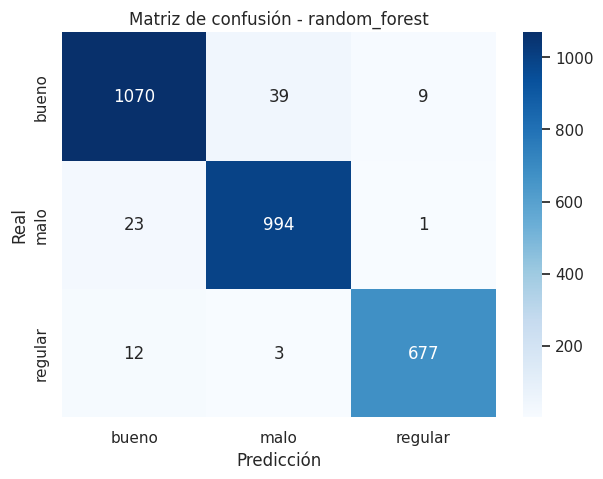

Ejemplos mal clasificados:


,filepath,y_true,y_pred
5,data/malo/Banana_Bad/IMG20200729190334.jpg,malo,bueno
65,data/bueno/Apple_Good/20190809_165925.jpg,bueno,malo
82,data/regular/Apple_Regular/IMG-20260603-WA0072...,regular,malo
106,data/malo/Apple_Bad/IMG_20190910_172559.jpg,malo,bueno
124,data/regular/Apple_Regular/n07740461_5486.jpg,regular,bueno
160,data/bueno/Apple_Good/20190809_165929.jpg,bueno,malo
180,data/bueno/Banana_Good/IMG_9062.JPG,bueno,malo
185,data/bueno/Apple_Good/20190809_165529.jpg,bueno,malo
192,data/regular/Apple_Regular/n07740461_7965.jpg,regular,bueno
211,data/bueno/Lime_Good/IMG20200729172230.jpg,bueno,malo


In [11]:
test_pred = best_model.predict(X_test_feat)

print("Accuracy:", accuracy_score(y_test_enc, test_pred))
print("Precision macro:", precision_score(y_test_enc, test_pred, average="macro", zero_division=0))
print("Recall macro:", recall_score(y_test_enc, test_pred, average="macro", zero_division=0))
print("F1 macro:", f1_score(y_test_enc, test_pred, average="macro"))
print("F1 micro:", f1_score(y_test_enc, test_pred, average="micro"))

report = classification_report(y_test_enc, test_pred, target_names=label_encoder.classes_, zero_division=0)
print(report)

cm = confusion_matrix(y_test_enc, test_pred)
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

errors_df = pd.DataFrame({
    "filepath": X_test_paths,
    "y_true": label_encoder.inverse_transform(y_test_enc),
    "y_pred": label_encoder.inverse_transform(test_pred),
})
errors_df = errors_df[errors_df["y_true"] != errors_df["y_pred"]]
print("Ejemplos mal clasificados:")
display(errors_df.head(10))

## 8. Modelado con deep learning

Si TensorFlow está disponible, se entrena una CNN simple sobre las imágenes redimensionadas y normalizadas.

In [12]:
cnn_history = None
cnn_model = None
cnn_test_metrics = None

if tf is None:
    print("TensorFlow no está disponible, por lo que se omite el entrenamiento CNN.")
else:
    image_size = IMG_SIZE
    batch_size = 32

    def decode_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, image_size)
        image = tf.cast(image, tf.float32) / 255.0
        label = tf.one_hot(label, depth=len(label_encoder.classes_))
        return image, label

    train_ds = tf.data.Dataset.from_tensor_slices((X_train_paths, y_train_enc))
    train_ds = train_ds.shuffle(buffer_size=len(X_train_paths), seed=42).map(decode_image, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val_paths, y_val_enc))
    val_ds = val_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    test_ds = tf.data.Dataset.from_tensor_slices((X_test_paths, y_test_enc))
    test_ds = test_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    data_augmentation = keras.Sequential([
        keras.layers.RandomFlip("horizontal", seed=42),
        keras.layers.RandomRotation(0.1, seed=42),
        keras.layers.RandomContrast(0.1, seed=42),
    ])

    cnn_model = keras.Sequential([
        keras.layers.Input(shape=(image_size[0], image_size[1], 3)),
        data_augmentation,
        keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(64, 3, activation="relu"),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(128, 3, activation="relu"),
        keras.layers.MaxPooling2D(),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(len(label_encoder.classes_), activation="softmax"),
    ])

    cnn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ]

    cnn_history = cnn_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=callbacks,
        verbose=1,
    )

    cnn_test_metrics = cnn_model.evaluate(test_ds, verbose=0)
    print(dict(zip(cnn_model.metrics_names, cnn_test_metrics)))

Epoch 1/20


E0000 00:00:1780619546.908756   31923 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1780619546.909572   32250 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1780619546.923204   31923 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7085 - loss: 0.6721 - val_accuracy: 0.8405 - val_loss: 0.4079
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8624 - loss: 0.3624 - val_accuracy: 0.8815 - val_loss: 0.3060
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9028 - loss: 0.2699 - val_accuracy: 0.9186 - val_loss: 0.2339
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9188 - loss: 0.2190 - val_accuracy: 0.9229 - val_loss: 0.2091
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9318 - loss: 0.1899 - val_accuracy: 0.9328 - val_loss: 0.1767
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9410 - loss: 0.1644 - val_accuracy: 0.9409 - val_loss: 0.1634
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9472 - loss: 0.1467 - val_accuracy: 0.9469 - val_loss: 0.1583
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9563 - loss: 0.1229 - val_accuracy: 0.955

## 9. Despliegue y guardado de artefactos

Se guardan el mejor modelo tradicional y, si existe, la CNN entrenada para reutilizarlos después en una interfaz o script de inferencia.

In [13]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, OUTPUT_DIR / f"best_traditional_model_{best_model_name}.pkl")
joblib.dump(label_encoder, OUTPUT_DIR / "label_encoder.pkl")
joblib.dump({
    "image_size": IMG_SIZE,
    "hist_bins": HIST_BINS,
    "class_names": CLASS_NAMES,
}, OUTPUT_DIR / "feature_config.pkl")

if cnn_model is not None and tf is not None:
    cnn_model.save(OUTPUT_DIR / "cnn_model.keras")

print(f"Artefactos guardados en: {OUTPUT_DIR.resolve()}")
print("Para guardar el notebook, usa File -> Save en VS Code o guarda el archivo .ipynb actual.")


def predict_image(image_path):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(image_path)
    features = extract_features(image_path)
    pred_encoded = best_model.predict([features])[0]
    pred_label = label_encoder.inverse_transform([pred_encoded])[0]
    return pred_label


# Ejemplo de uso:
# predict_image("data/regular/ejemplo.jpg")

Artefactos guardados en: /home/juanrosero/Documents/SeptimoSemestre/APO3/Proyecto/proyectoFinalAPO3/outputs
Para guardar el notebook, usa File -> Save en VS Code o guarda el archivo .ipynb actual.


## 10. Inferencia en nueva imagen

Esta celda permite realizar predicciones sobre una imagen nueva usando el mejor modelo guardado.